In [3]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 압축 푼 폴더 경로
folder_path = './cifar-10-batches-py/'

# 데이터 가져오기
def load_cifar_batch(file_name):
    with open(folder_path + file_name, 'rb') as f:
        my_dict = pickle.load(f, encoding='bytes')
        x_data = my_dict[b'data']
        y_data = my_dict[b'labels']
    return x_data, y_data

print("importing data..")
x_train1, y_train1 = load_cifar_batch('data_batch_1')
x_test_full, y_test_full = load_cifar_batch('test_batch')
print("Finished")

importing data..
Finished


In [4]:
!pip install scikit-learn seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# 5000개 train, 1000개 test
train_x_small = x_train1[:5000]
train_y_small = np.array(y_train1[:5000])

test_x_small = x_test_full[:1000]
test_y_small = np.array(y_test_full[:1000])

# Flatten images from 32 x 32 x 3 to 3072
def flatten(data):
    # 32x32x3 이미지 형태로 만들기
    reshaped_img = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    
    # 3072로 쫙 펴기
    flat_img = reshaped_img.reshape(reshaped_img.shape[0], -1)
    return flat_img

final_train_x = flatten(train_x_small)
final_test_x = flatten(test_x_small)

print("Train shape:", final_train_x.shape) # (5000, 3072)
print("Test shape:", final_test_x.shape)   # (1000, 3072)

Train shape: (5000, 3072)
Test shape: (1000, 3072)


In [6]:
class MyCustomKNN:
    def __init__(self):
        pass
        
    def train_data(self, x, y):
        # 데이터를 저장만
        self.x_tr = x
        self.y_tr = y
        
    def predict(self, test_x, k_val, dist_metric='L1'):
        num_test = test_x.shape[0]
        y_pred = np.zeros(num_test)
        
        # 테스트 이미지 개수만큼 반복
        for i in range(num_test):
            if dist_metric == 'L1':
                # L1 distance
                dist = np.sum(np.abs(self.x_tr - test_x[i, :]), axis=1)
            elif dist_metric == 'L2':
                # L2 distance
                dist = np.sqrt(np.sum(np.square(self.x_tr - test_x[i, :]), axis=1))
                
            # 거리가 가장 짧은 k개의 인덱스 찾기
            min_indices = np.argsort(dist)[:k_val]
            
            # 그 인덱스들 label 모으기
            closest_labels = self.y_tr[min_indices]
            
            # 다수결 투표
            vote = Counter(closest_labels)
            y_pred[i] = vote.most_common(1)[0][0]
                
        return y_pred

In [7]:
my_knn = MyCustomKNN()
my_knn.train_data(final_train_x, train_y_small)

k_list = [1, 3, 5, 7, 9] # K 값들
metrics = ['L1', 'L2']

# 결과 저장할 딕셔너리
results_acc = {}
best_pred = None
best_acc = 0

print("----start----")
for m in metrics:
    for k in k_list:
        print(f"\n[ distance: {m}, K: {k} ] testing..")
        
        # 만든 함수로 예측
        preds = my_knn.predict(final_test_x, k_val=k, dist_metric=m)
        
        # 정확도 계산
        accuracy = np.mean(preds == test_y_small)
        results_acc[f"{m}_K{k}"] = accuracy
        print(f"==> K={k}, {m} accuracy: {accuracy * 100:.2f}%")
        
        # confusion matrix 위한 제일 좋은 결과 저장
        if accuracy > best_acc:
            best_acc = accuracy
            best_pred = preds
            best_model_name = f"{m}_K{k}"

----start----

[ distance: L1, K: 1 ] testing..
==> K=1, L1 accuracy: 21.30%

[ distance: L1, K: 3 ] testing..
==> K=3, L1 accuracy: 21.80%

[ distance: L1, K: 5 ] testing..
==> K=5, L1 accuracy: 21.40%

[ distance: L1, K: 7 ] testing..
==> K=7, L1 accuracy: 20.50%

[ distance: L1, K: 9 ] testing..
==> K=9, L1 accuracy: 21.70%

[ distance: L2, K: 1 ] testing..
==> K=1, L2 accuracy: 17.90%

[ distance: L2, K: 3 ] testing..
==> K=3, L2 accuracy: 19.10%

[ distance: L2, K: 5 ] testing..
==> K=5, L2 accuracy: 20.50%

[ distance: L2, K: 7 ] testing..
==> K=7, L2 accuracy: 20.80%

[ distance: L2, K: 9 ] testing..
==> K=9, L2 accuracy: 21.20%


In [8]:
import pandas as pd
from sklearn.metrics import confusion_matrix
from IPython.display import display

print(f"\n=== Confusion Matrix (Best: {best_model_name}) ===")

# 오차 행렬 계산
conf_mat = confusion_matrix(test_y_small, best_pred)

# 알아보기 쉽게 이름표 달아주기
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# 데이터프레임(표)으로 변환
df_cm = pd.DataFrame(conf_mat, index=class_names, columns=class_names)
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'

# 주피터 노트북용 깔끔한 표 출력
display(df_cm)


=== Confusion Matrix (Best: L1_K3) ===


Predicted,0,1,2,3,4,5,6,7,8,9
Actual,,,,,,,,,,
0,60,1,15,1,4,0,5,0,17,0
1,28,7,15,1,6,3,3,4,21,1
2,35,0,36,3,11,2,3,2,7,1
3,29,1,19,4,12,15,9,4,10,0
4,25,1,23,6,21,3,5,1,5,0
5,22,2,22,9,9,10,2,3,6,1
6,23,0,39,5,15,13,7,1,9,0
7,30,2,22,3,11,8,2,8,15,1
8,30,2,5,2,4,3,0,1,58,1



--- 5-fold Cross Validation ---
K=1
-> K=1 accuracy: 29.92%
K=3
-> K=3 accuracy: 28.80%
K=5
-> K=5 accuracy: 30.50%
K=7
-> K=7 accuracy: 31.42%
K=9
-> K=9 accuracy: 31.12%


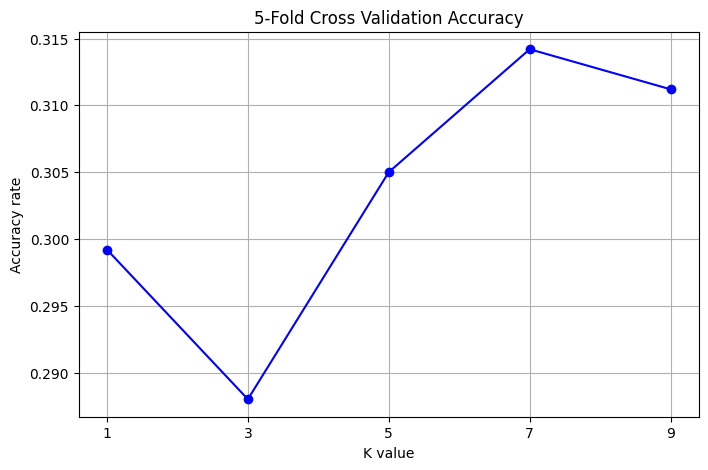

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import time

print("\n--- 5-fold Cross Validation ---")
start_time = time.time()

cv_accuracies_fast = []

# 앞서 설정한 K값 리스트: [1, 3, 5, 7, 9]
for k in k_list:
    print(f"K={k}")
    
    # p=1: L1(Manhattan) 거리, p=2: L2(Euclidean) 거리
    knn_fast = KNeighborsClassifier(n_neighbors=k, p=1, n_jobs=-1)
    
    scores = cross_val_score(knn_fast, final_train_x, train_y_small, cv=5)
    
    mean_acc = np.mean(scores)
    cv_accuracies_fast.append(mean_acc)
    print(f"-> K={k} accuracy: {mean_acc*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(k_list, cv_accuracies_fast, marker='o', linestyle='-', color='blue')
plt.title('5-Fold Cross Validation Accuracy')
plt.xlabel('K value')
plt.ylabel('Accuracy rate')
plt.xticks(k_list)
plt.grid(True)
plt.show()